Dataset loaded successfully!
Dataset shape: (891, 12)
First five rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  

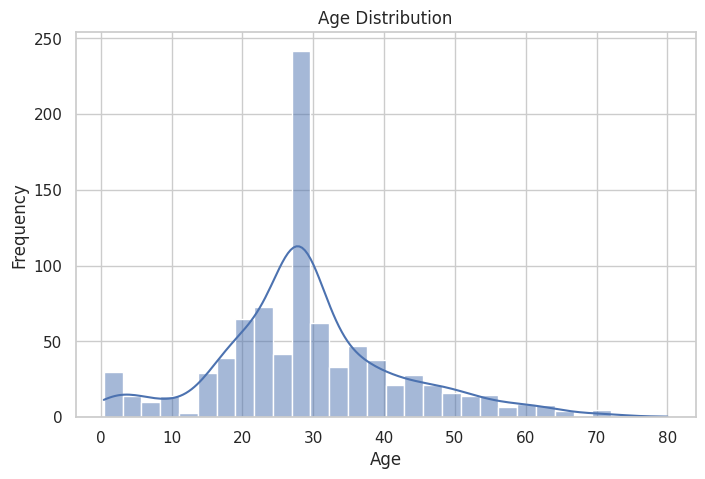

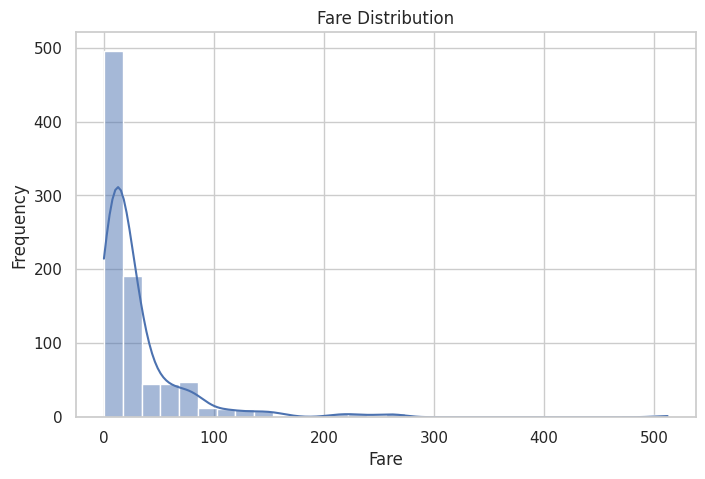

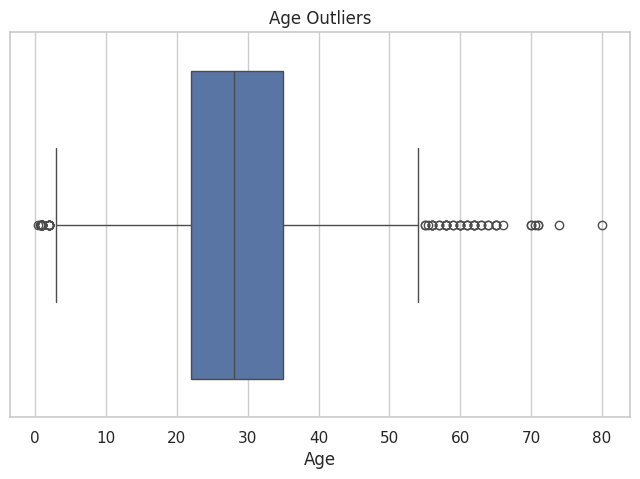

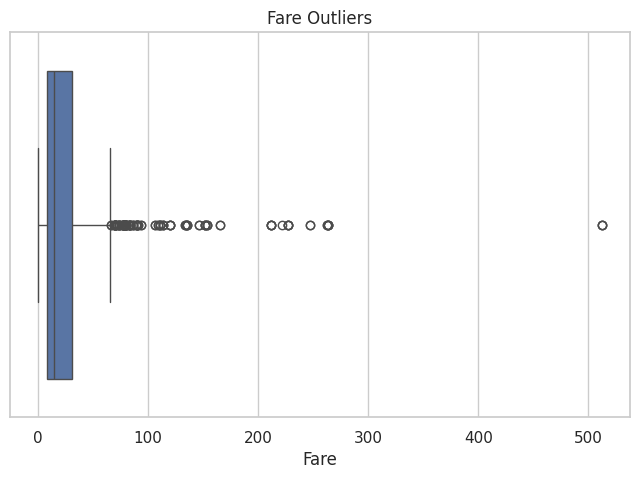

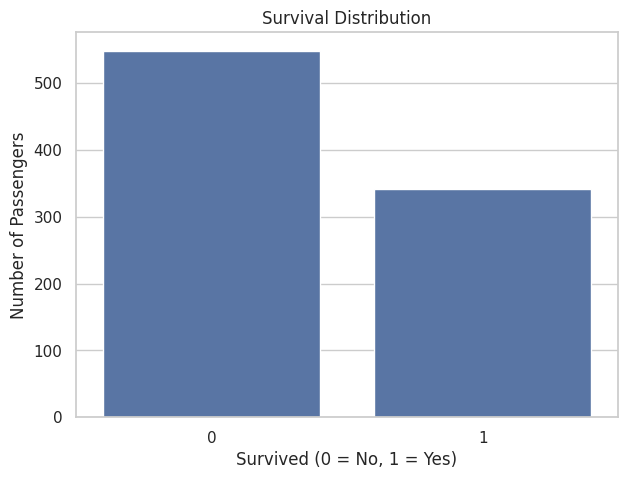

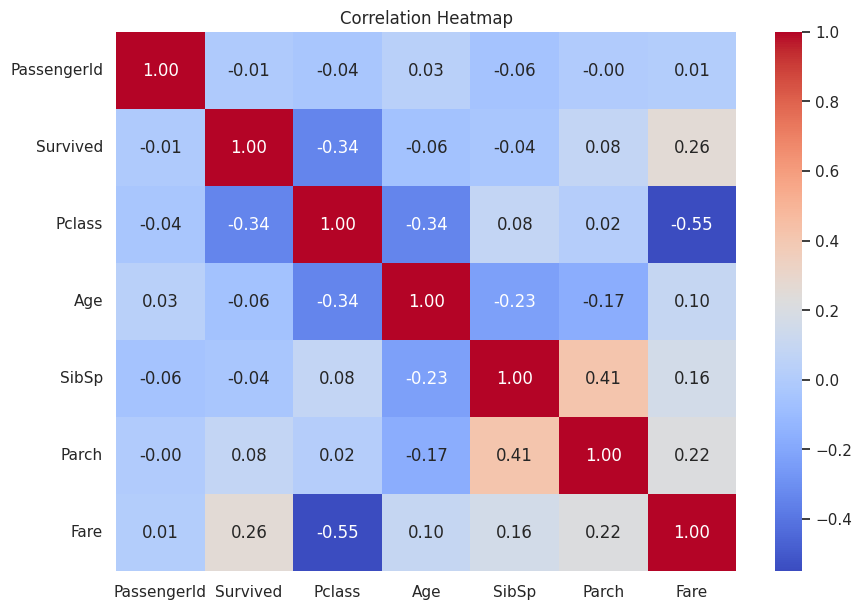

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# TASK 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Load any public dataset (CSV format).
sns.set_theme(style="whitegrid")
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
# Display a message to confirm that the dataset was loaded
print("Dataset loaded successfully!")

# Display the number of rows and columns
print("Dataset shape:", df.shape)

# Display the first five rows
print("First five rows:")
print(df.head())

# Display information about the dataset
print("Dataset Information:")
df.info()

# Descriptive Statistics
# Select only numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns
# Calculate the mean
print("Mean:")
print(df[numeric_columns].mean())
# Calculate the median
print("Median:")
print(df[numeric_columns].median())
# Calculate the standard deviation
print("Standard Deviation:")
print(df[numeric_columns].std())
# Display a complete statistical summary
print("Complete Descriptive Statistics:")
print(df.describe())

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Missing Values Percentage:")
print(missing_percentage)

# Handle missing values
# Replace missing Age values with the median Age.
df["Age"] = df["Age"].fillna(df["Age"].median())
# Replace missing Embarked values with the most frequent value.
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
# Replace missing Fare values with the median Fare.
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
# Check missing values again
print("Missing Values After Cleaning:")
print(df.isnull().sum())

# Check for duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
# Remove duplicate rows
df = df.drop_duplicates()

# Detect outliers using the IQR method
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]
    return outliers, lower_limit, upper_limit

# Detect Age outliers
age_outliers, age_lower, age_upper = detect_outliers(df, "Age")
print("Number of Age outliers:", len(age_outliers))
print("Age lower limit:", age_lower)
print("Age upper limit:", age_upper)

# Detect Fare outliers
fare_outliers, fare_lower, fare_upper = detect_outliers(df, "Fare")
print("Number of Fare outliers:", len(fare_outliers))
print("Fare lower limit:", fare_lower)
print("Fare upper limit:", fare_upper)

# Visualize Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Visualize Fare distribution
plt.figure(figsize=(8, 5))
sns.histplot(
    df["Fare"],
    bins=30,
    kde=True
)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

# Visualize Age outliers using a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Age"])
plt.title("Age Outliers")
plt.xlabel("Age")
plt.show()

#  Visualize Fare outliers using a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.xlabel("Fare")
plt.show()

# Survival distribution
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="Survived"
)
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

# Correlation heatmap
correlation = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()
